In [122]:
# %%
import sys
sys.path.insert(0, '..')
import helper_functions
from constants import *

import eelbrain
import numpy as np
import mne
import matplotlib.gridspec as gridspec
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

In [123]:
# %%
SUBJECTS = helper_functions.get_subjects()

checks = [
    (PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD, False),
    (PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD, False),
    (PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD, False),
    (PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD, False),
]

# Latencies (seconds) per model
latencies = {
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD): [-0.190],
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD): [-0.140, -0.08],
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD): [-0.35, -0.080],
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD): [-0.095],
}

colors = {
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD): 'tab:blue',
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD): 'tab:orange',
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD): 'tab:green',
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD): 'tab:red',
}

In [124]:
# %%
trf_data, n_subjects = helper_functions.load_trfs(checks, trf_dir=MAT_FILE_TRF_DIR)

# Compute grand mean TRFs
backward_trfs = {}
for predictor, attention, model, padded in checks:
    model_name = helper_functions.get_trf_model_name(predictor, attention, model, padded)
    trf_list   = [trf.h_scaled[0] if isinstance(trf.h_scaled, tuple) else trf.h_scaled 
                  for trf in trf_data[model_name]]
    backward_trfs[model_name] = eelbrain.combine(trf_list).mean('case')
    print(f"  ✓ Grand mean computed ({len(trf_list)} subjects)")

  ✓ S1
  ✓ S2
  ✓ S3
  ✓ S4
  ✓ S5
  ✓ S6
  ✓ S7
  ✓ S8
  ✓ S9
  ✓ S10
  ✓ S11
  ✓ S12
  ✓ S13
  ✓ S14
  ✓ S15
  ✓ S16
  ✓ S17
  ✓ S18

Loaded: 18 subjects | Skipped: 0 subjects
  ✓ Grand mean computed (18 subjects)
  ✓ Grand mean computed (18 subjects)
  ✓ Grand mean computed (18 subjects)
  ✓ Grand mean computed (18 subjects)


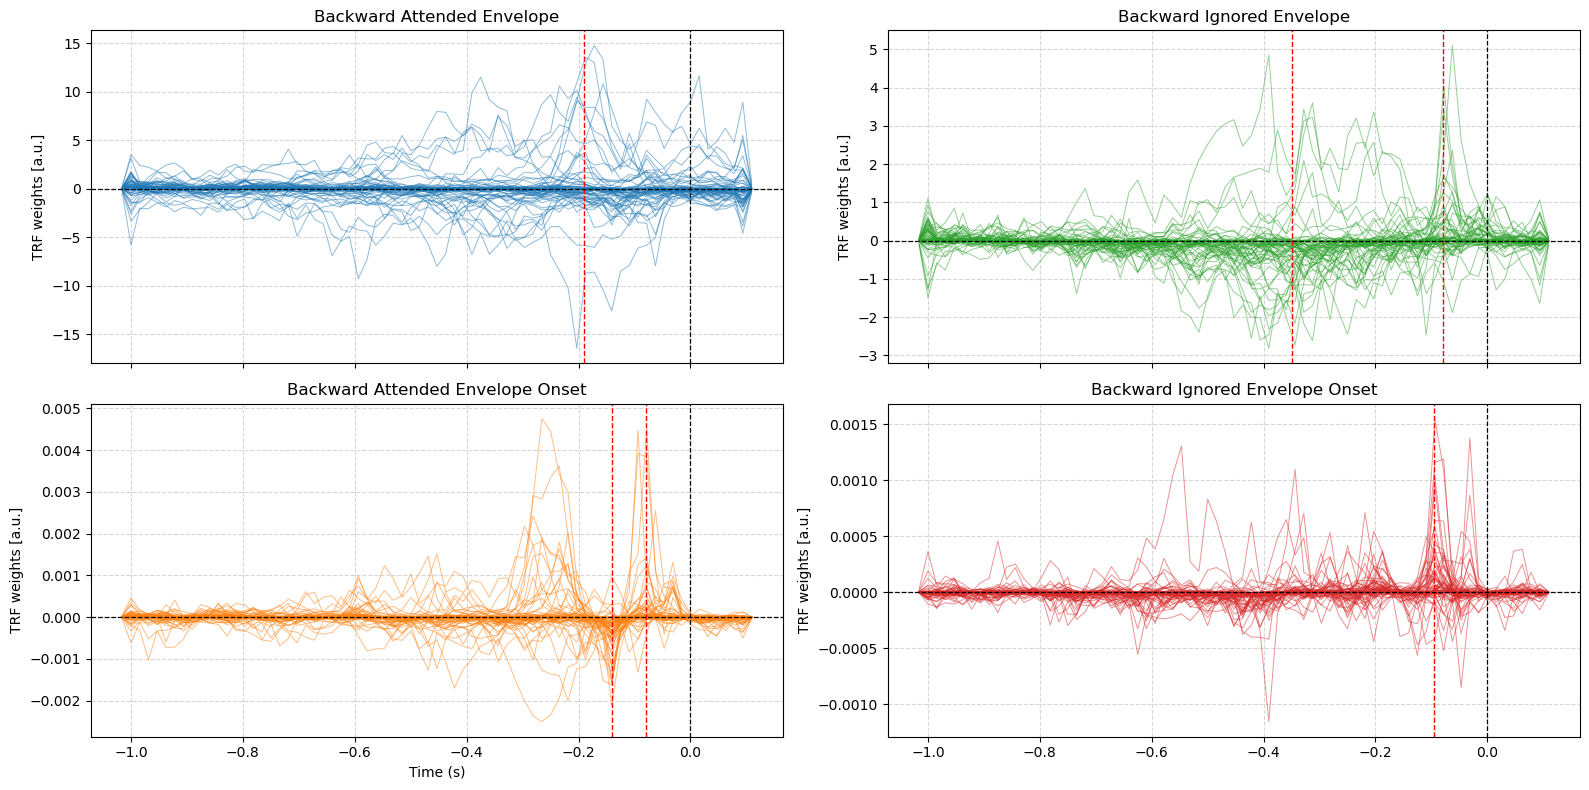

In [125]:
fig, axes = plt.subplots(int(len(checks) / 2), int(len(checks) / 2), figsize=(16, 8), sharex=True)

for i, (predictor, attention, model, padded) in enumerate(checks):
    model_name = helper_functions.get_trf_model_name(predictor, attention, model, padded)
    trf        = backward_trfs[model_name]
    trf_plot   = trf.mean('predictor') if 'predictor' in trf.dims else trf

    row, col = i // 2, i % 2  # ← correct 2D indexing

    time_s = np.array(trf_plot.time.times)
    for sensor_idx in range(trf_plot.x.shape[0]):
        axes[row][col].plot(time_s, trf_plot.x[sensor_idx],
                            color=colors[model_name], linewidth=0.7, alpha=0.5)

    for t in latencies[model_name]:
        axes[row][col].axvline(t, color='red', linestyle='--', linewidth=1)

    axes[row][col].axhline(0, linestyle='--', color='black', linewidth=0.9)
    axes[row][col].axvline(0, linestyle='--', color='black', linewidth=0.9)
    axes[row][col].set_title(model_name.replace('_', ' ').title(), fontsize=12)
    axes[row][col].set_ylabel('TRF weights [a.u.]')
    axes[row][col].grid(True, linestyle='--', alpha=0.5)

axes[-1][0].set_xlabel('Time (s)')
plt.tight_layout()
fig.savefig(FIGURES_DIR / f'{FUGLSANG}-backward-trf.pdf', bbox_inches='tight')
plt.show()

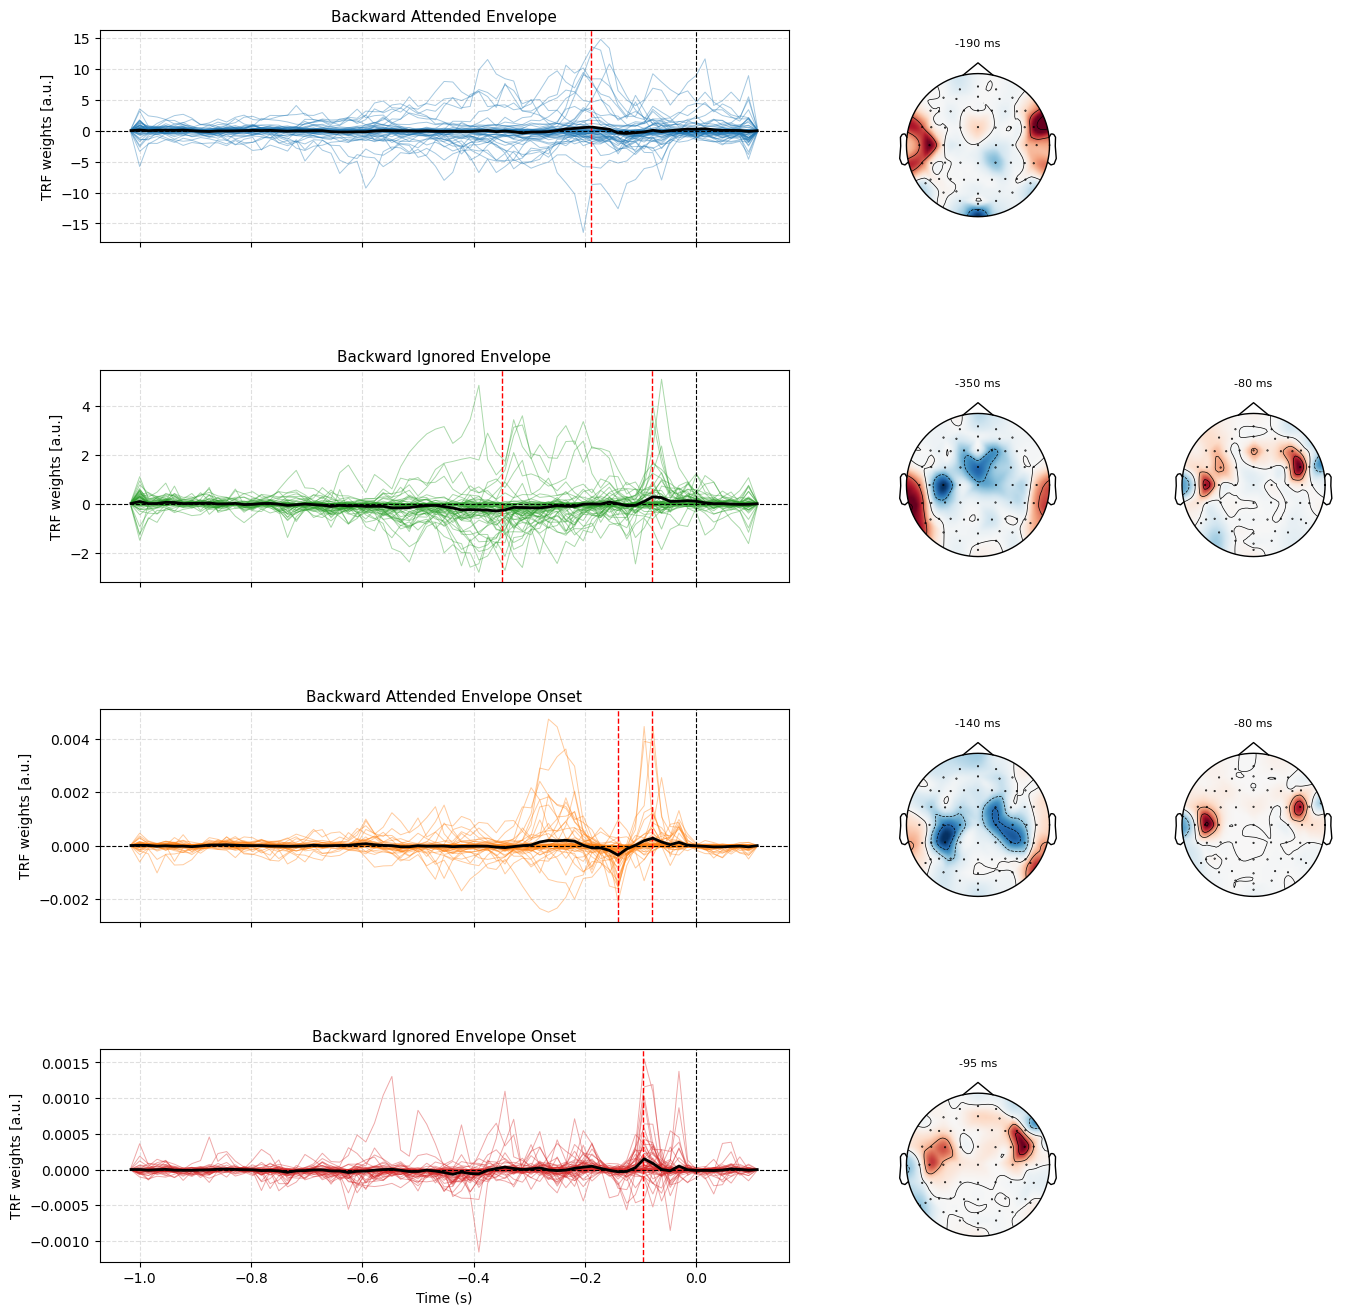

In [ ]:
fig = plt.figure(figsize=(16, 16))

# Each model = 1 row, columns = TRF (wide) + max_topos
gs = fig.add_gridspec(
    n_rows * n_cols,           # one row per model
    1 + max_topos,             # TRF + topo columns
    width_ratios=[4] + [1]*max_topos,
    hspace=0.6,
    wspace=0.3
)

for i, (predictor, attention, model, padded) in enumerate(checks):
    model_name = helper_functions.get_trf_model_name(predictor, attention, model, padded)
    trf        = backward_trfs[model_name]
    trf_plot   = trf.mean('predictor') if 'predictor' in trf.dims else trf
    lats       = latencies[model_name]

    row = i  # one row per model

    # ======================
    # A) TRF (left)
    # ======================
    ax_trf = fig.add_subplot(gs[row, 0])

    time_s = np.array(trf_plot.time.times)

    for sensor_idx in range(trf_plot.x.shape[0]):
        ax_trf.plot(
            time_s,
            trf_plot.x[sensor_idx],
            color=colors[model_name],
            linewidth=0.7,
            alpha=0.4
        )

    mean_trf = np.array(trf_plot.x).mean(axis=0)
    ax_trf.plot(time_s, mean_trf, color='black', linewidth=2.0, zorder=5)

    for t in lats:
        ax_trf.axvline(t, color='red', linestyle='--', linewidth=1)

    ax_trf.axhline(0, linestyle='--', color='black', linewidth=0.8)
    ax_trf.axvline(0, linestyle='--', color='black', linewidth=0.8)

    ax_trf.set_title(model_name.replace('_', ' ').title(), fontsize=11)
    ax_trf.set_ylabel('TRF weights [a.u.]')

    if row == len(checks) - 1:
        ax_trf.set_xlabel('Time (s)')
    else:
        ax_trf.set_xticklabels([])

    ax_trf.grid(True, linestyle='--', alpha=0.4)

    # ======================
    # B) Topomaps (right)
    # ======================
    for j, t in enumerate(lats):
        ax_topo = fig.add_subplot(gs[row, 1 + j])

        t_idx = np.argmin(np.abs(time_s - t))
        topo_data = np.array(trf_plot.x[:, t_idx])

        montage   = mne.channels.make_standard_montage('biosemi64')
        ch_names  = montage.ch_names + ['EXG1', 'EXG2']
        ch_types  = ['eeg'] * 64 + ['misc', 'misc']
        info      = mne.create_info(ch_names, EEG_SAMPLING_RATE, ch_types)
        info.set_montage(montage, on_missing='ignore')

        mne.viz.plot_topomap(
            topo_data,
            info,
            axes=ax_topo,
            show=False,
            contours=4,
            cmap='RdBu_r',
            vlim=(-np.abs(topo_data).max(), np.abs(topo_data).max()),
        )

        ax_topo.set_title(f'{int(t * 1000)} ms', fontsize=8)

#plt.suptitle(f'{FUGLSANG} — Backward TRF', fontsize=14)
fig.savefig(FIGURES_DIR / f'{FUGLSANG}-backward-trf.pdf', bbox_inches='tight')
plt.show()